<a href="https://colab.research.google.com/github/mwetmore05/A02-eda-and-visualization/blob/main/notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment: Exploratory Data Analysis

**Q1.** In class, we talked about how to compute the sample mean of a variable $X$,
$$
m(X) = \dfrac{1}{N} \sum_{i=1}^N x_i
$$
and sample covariance of two variables $X$ and $Y$,
$$
\text{cov}(X,Y) = \dfrac{1}{N} \sum_{i=1}^N (x_i - m(X))(y_i - m(Y))).
$$
Recall, the sample variance of $X$ is
$$
s^2 = \dfrac{1}{N} \sum_{i=1}^N (x_i - m(X))^2.
$$
It can be very helpful to understand some basic properties of these statistics. If you want to write your calculations on a piece of paper, take a photo, and upload that to your GitHub repo, that's probably easiest.

1. Show that $m(a + bX) = a+b \times m(X)$.
2. Show that $\text{cov}(X,a+bY) = b \times \text{cov}(X,Y)$
3. Show that $\text{cov}(a+bX,a+bX) = b^2 \text{cov}(X,X) $, and in particular that $\text{cov}(X,X) = s^2 $.
4. Consider a non-decreasing transformation $g()$. Is is always true that $m(g(X))= g(m(X))$?

**Q2.** This question looks at financial transfers from foreign entities to American universities. In particular, from which countries and giftors are the gifts coming from, and to which institutions are they going? For this question, `.groupby([vars]).count()` and `.groupby([vars]).sum()` will be especially useful to tally the number of occurrences and sum the values of those occurrences.

1. Load the `./data/ForeignGifts_edu.csv` dataset.
2. For `Foreign Gift Amount`, create a histogram and describe the variable. Describe your findings.
3. For `Gift Type`, create a histogram or value counts table. What proportion of the gifts are contracts, real estate, and monetary gifts?
4. Create a kernel density plot of the log of `Foreign Gift Amount`, and then a kernel density plot of the log of `Foreign Gift Amount` conditional on gift type. Do you notice any patterns?
5. What are the top 15 countries in terms of the number of gifts? What are the top 15 countries in terms of the amount given?
6. Which giftors provide the most money, in total?

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** Maggie Wetmore

**Date:** 9/926

In [ ]:
# Your Phase 1 solution to the problem goes here.

#1.

See the file uploaded to repository.

#2.1.

In [3]:
import pandas as pd #importing packages
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
FG = pd.read_csv('/content/ForeignGifts_edu.csv') #downloading the data
FG.head()

FG['Foreign Gift Amount'] = pd.to_numeric( #cleaning the data by assuring no , or $
    FG['Foreign Gift Amount']
        .astype(str)
        .str.replace('$', '', regex=False)
        .str.replace(',', '', regex=False),
    errors='coerce'
)

#2.2.

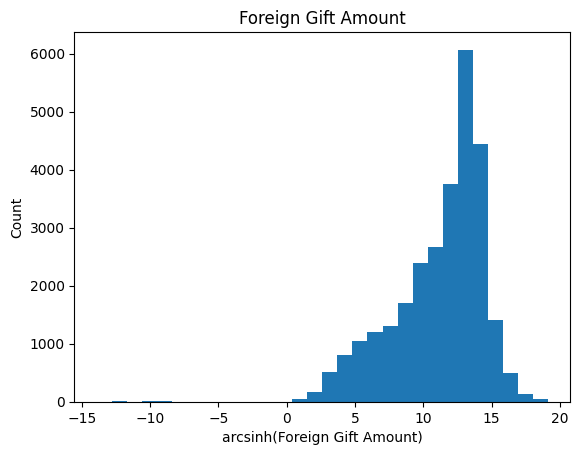

In [4]:
FG["Foreign Gift Amount"] = np.arcsinh(FG["Foreign Gift Amount"]) #tranforming for the long tail fo the histogram like we did in class
FG["Foreign Gift Amount"].hist(bins=30, grid=False)
plt.title("Foreign Gift Amount") #labeling the histogram
plt.xlabel("arcsinh(Foreign Gift Amount)")
plt.ylabel("Count")
plt.show()


Findings: left skewed histogram. One peak. There could be potential outliars given the visual skewedness.

#2.3.

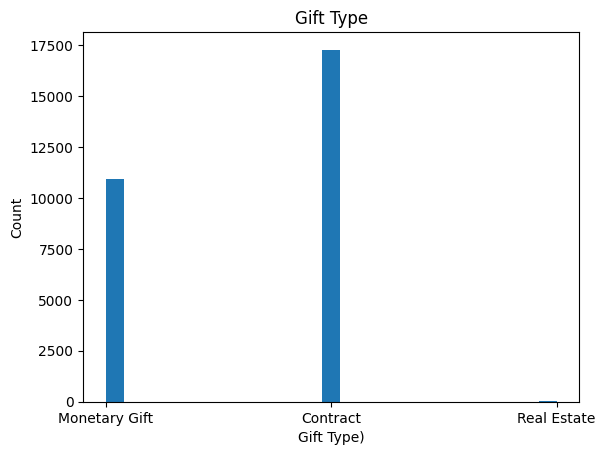

Proportion of Monetary Gifts in Foreign Gift's: 0.3875128450444704
Proportion of Contracts in Foreign Gift's: 0.6120973742957372
Proportion of Real Estate in Foreign Gift's: 0.00038978065979235324


In [7]:
 #tranforming for the long tail fo the histogram like we did in class
FG["Gift Type"].hist(bins=25, grid=False) #mkaing histogram no grid, and 25 bins
plt.title("Gift Type")
plt.xlabel("Gift Type)")
plt.ylabel("Count")
plt.show()


Monetary_Gift_proportion = (
    FG["Gift Type"] == "Monetary Gift").sum() / len(FG["Gift Type"])

print("Proportion of Monetary Gifts in Foreign Gift's:", Monetary_Gift_proportion)

Contract_proportion = (
    FG["Gift Type"] == "Contract").sum() / len(FG["Gift Type"])

print("Proportion of Contracts in Foreign Gift's:", Contract_proportion)

Real_Estate_proportion = (
    FG["Gift Type"] == "Real Estate").sum() / len(FG["Gift Type"]) #calculating the sum of real estate/ contract/ monetary gift (what I did i the previous lines) / total gift types

print("Proportion of Real Estate in Foreign Gift's:", Real_Estate_proportion) #printing out labels and proprotion with it

#2.4.

/usr/local/lib/python3.13/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


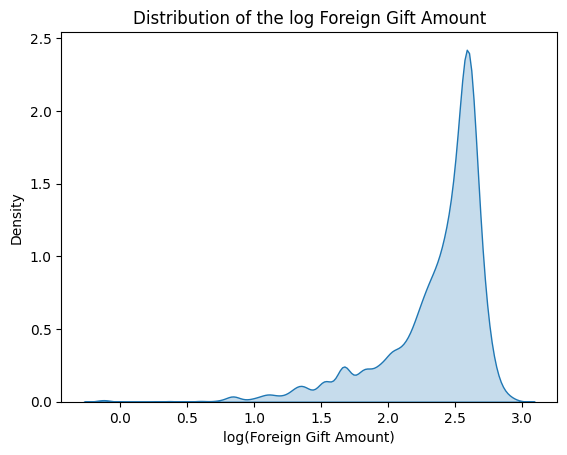

In [9]:
FG['Log Foreign Gift Amount'] = np.log(  #getting log from pandas
    FG['Foreign Gift Amount']) #logging with np the foreign gift amount

sns.kdeplot( #kernel density plot of log of foreign gift amount
    data=FG,
    x='Log Foreign Gift Amount',
    fill=True) #filling because looks better

plt.title('Distribution of the log Foreign Gift Amount') #labeling
plt.xlabel('log(Foreign Gift Amount)')
plt.ylabel('Density')
plt.show()

Findings:left skwed, single peak. still not symmetric.

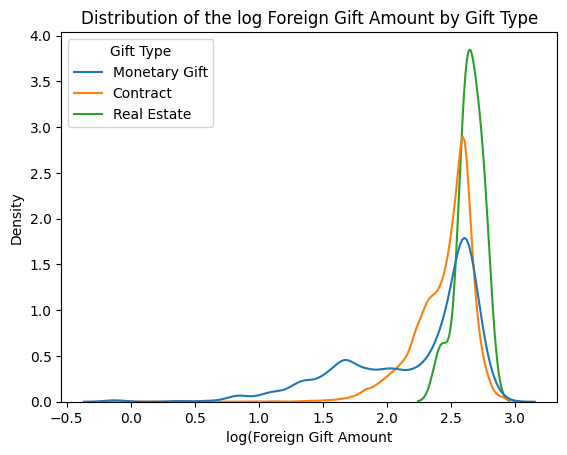

In [ ]:
#now same but conditional on gift type
sns.kdeplot(
    data=FG,
    x='Log Foreign Gift Amount',
    hue='Gift Type', #conditional statement
    common_norm=False)

plt.title('Distribution of the log Foreign Gift Amount by Gift Type') #labeling!
plt.xlabel('log(Foreign Gift Amount')
plt.ylabel('Density')
plt.show()

The log transformation reduces the strong skew in the histogram/KDE that is seem in the previous lot. It still has a long tail but toward smaller amounts. When the foreign gift amounts are seperated by gift types the reak esatet is the smalled amount and narrowest distribution, compared to the contract with more concentrated large amounts. But the proportion of contracts is about .0003 so that is very important to note when doing further analysis.

#2.5.

In [ ]:
top_15_giftgivers_by_count = (
    FG['Country of Giftor']
    .value_counts()
    .head(15)) #creating top 15 names and top counts and showing top 15

top_15_giftgivers_by_count

,count
Country of Giftor,
ENGLAND,3655
CHINA,2461
CANADA,2344
JAPAN,1896
SWITZERLAND,1676
SAUDI ARABIA,1610
FRANCE,1437
GERMANY,1394
HONG KONG,1080


In [ ]:
top_15_giftgivers_by_amount = (
    FG.groupby('Country of Giftor')['Foreign Gift Amount']
    .sum()
    .sort_values(ascending=False) #grouping by foreign gift amiunt, summing all the gifts to show total  15
    .head(15))

top_15_giftgivers_by_amount

,Foreign Gift Amount
Country of Giftor,
ENGLAND,36809.943101
CHINA,28225.510982
CANADA,21333.704080
JAPAN,20751.397037
SAUDI ARABIA,19347.062506
SWITZERLAND,19071.613687
FRANCE,15599.092109
GERMANY,14738.055125
HONG KONG,12459.739488


#2.6

In [ ]:
top_15_gifters = (
    FG.groupby('Giftor Name')['Foreign Gift Amount']
    .sum()
    .sort_values(ascending=False) #showing total froeign gift amount top giftor names
    .head(15))

top_15_gifters

,Foreign Gift Amount
Giftor Name,
Saudi Arabian Cultural Mission,5619.041181
Qatar Foundation,3723.179372
Anonymous,3646.566941
Human Frontier Science Program,2677.252901
Novartis Pharmaceuticals Corp,2255.583706
Royal Embassy of Saudi Arabia,2208.716884
Acerta Pharma B.V.,2078.507347
Contracting Party,1861.464939
Qatar National Research Fund,1656.435430


## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** [To be provided]
- **AI tool and model used:** [To be provided]

### *Prompts used

1. [Paste prompt]
2. [Paste follow-up prompt]

### *AI-proposed changes


[Paste the AI's concise numbered list verbatim.]

1. ...
2. ...

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Accept / modify / reject | ... |
| 2 | Accept / modify / reject | ... |

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

In [ ]:
# Your Phase 2 solution to the problem goes here.


### *Reflection on AI assistance
In your own words without generative AI.

[In 150–300 words, describe the main improvements, AI mistakes or limitations, how the final solution was verified, and any remaining concerns.]